In [1]:
import os
import sys
sys.path.append("../../src")

import numpy as np
from numba import njit
from scipy.stats import ortho_group
from tqdm import tqdm
import matplotlib.pyplot as plt
from skimage import data
import matplotlib.image as mpimg
import cv2

from python_utils.visualization_utils import display_matrix, plot_bss_comparison, subplot_1D_signals, visualize_flattened_images
from python_utils.ml_utils import min_max_normalize
from bss.bss_utils import generate_uncorrelated_uniform_sources, addWGN
from bss.PredictiveDecorrBSS import PredictiveDecorrBSS

In [2]:
image_paths = '../../data/TestImages'
images = []
for im_dir in os.listdir(image_paths):
    try:
        images.append(mpimg.imread(os.path.join(image_paths,im_dir)))
    except:
        pass

In [3]:
image_height_and_width = [454, 605]
small_images = np.zeros((len(images),image_height_and_width[0]* image_height_and_width[1]* 3))
small_to_large_image_size_ratio = 0.15
for i in range(len(images)):
    small_img = cv2.resize(images[i], # original image
                           (0,0), # set fx and fy, not the final size
                           fx=small_to_large_image_size_ratio, 
                           fy=small_to_large_image_size_ratio, 
                           interpolation=cv2.INTER_NEAREST)
    print(small_img.shape)
    if small_img.shape[0] == 486:
        small_img = cv2.resize(small_img, (0,0), fx = 454/486, fy = 605/648)

    small_images[i] = small_img.reshape(-1,)/255

small_images.shape

(486, 648, 3)
(486, 648, 3)
(486, 648, 3)
(486, 648, 3)
(486, 648, 3)
(486, 648, 3)
(486, 648, 3)
(454, 605, 3)
(454, 605, 3)
(454, 605, 3)
(454, 605, 3)
(454, 605, 3)
(454, 605, 3)
(454, 605, 3)


(14, 824010)

In [4]:
def visualize_flattened_images_rgb(I, imsize, title="", height=5, width=15):
    """
    Visualizes RGB images from a matrix of flattened vectors.
    
    Args:
        I (ndarray): Matrix of shape (n_images, n_pixels_total).
                     Assumes n_pixels_total = imsize[0] * imsize[1] * 3
        imsize (tuple): Original dimensions of the image (height, width).
        title (str): Global title for the figure.
        height (int): Figure height.
        width (int): Figure width.
    """
    n_images = I.shape[0]
    
    fig, ax = plt.subplots(1, n_images, figsize=(width, height))
    fig.suptitle(title, fontsize=16, fontweight='bold', y=0.95)
    
    if n_images == 1:
        ax = [ax]
    
    for i in range(n_images):
        # 1. Reshape back to (Height, Width, 3)
        # Note: If your data is flattened as (3, H, W), use .reshape(3, *imsize).transpose(1, 2, 0)
        img_rgb = I[i, :].reshape(imsize[0], imsize[1], 3)
        
        # 2. Normalization / Clipping
        # RGB images in imshow must be [0, 1] for floats or [0, 255] for ints.
        # We'll use a robust scaling to handle BSS artifacts/outliers.
        img_min = np.percentile(img_rgb, 1)
        img_max = np.percentile(img_rgb, 99)
        
        # Robustly scale to [0, 1]
        img_display = (img_rgb - img_min) / (img_max - img_min + 1e-8)
        img_display = np.clip(img_display, 0, 1)
        
        # 3. Display
        ax[i].imshow(img_display, interpolation='nearest')
        ax[i].axis('off')
        ax[i].set_title(f"Image {i}", fontsize=12)

    plt.subplots_adjust(
        right=0.95, left=0.05, bottom=0.05, top=0.85, wspace=0.1
    )
    plt.show()

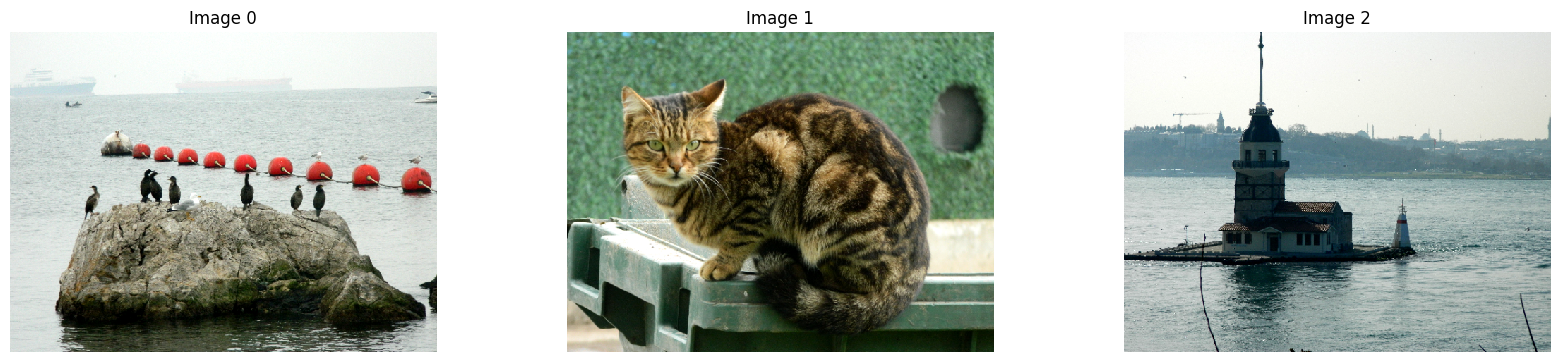

<IPython.core.display.Math object>

In [5]:
S = small_images[[0, 1, 5]]
visualize_flattened_images_rgb(S, imsize = image_height_and_width, height = 4, width = 18)
display_matrix(np.corrcoef(S))

# Generate Sources and Mix Them (10 by 5 case)

The following is the mixture matrix A


<IPython.core.display.Math object>

Input SNR is : 40.00368414337514


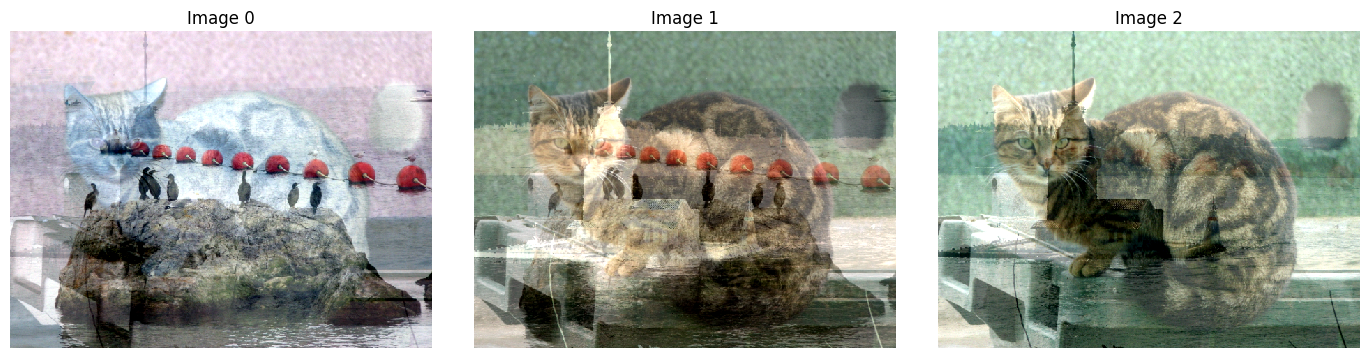

In [6]:
seed = 1250
np.random.seed(seed)
# # 1. Load and normalize sources to [0, 1] for Simplex/NN-Antisparse domains
# s1 = data.camera().astype(float) / 255.0
# s2 = data.gravel().astype(float) / 255.0
# s3 = data.grass().astype(float) / 255.0

# # s3 = data.coins().astype(float) / 255.0
# # s3 = data.text().astype(float) / 255.0

# print(s1.shape, s2.shape, s3.shape)
# # Ensure they are the same size (cropping to the smallest common dimensions)
# h, w = 512, 512 
# S_raw = np.stack([s1[:h, :w], s2[:h, :w], s3[:h, :w]], axis=0) # Shape: (3, 512, 512)
# NumberofSources = S_raw.shape[0]
# n_pixels = h * w

# # Flatten for the BSS model: (n_sources, T)
# S = S_raw.reshape(NumberofSources, n_pixels)
# S = min_max_normalize(S, axis = 1)
# visualize_flattened_images(S, imsize=(h, w))
NumberofSources = S.shape[0]
NumberofMixtures = NumberofSources
# # Generate Mxr random mixing from i.i.d N(0,1)
# A = np.random.randn(NumberofMixtures, NumberofSources) # Random Gaussian mixing matrix
# A = np.random.uniform(0.3, 0.7, (NumberofMixtures, NumberofSources))
A = -ortho_group.rvs(dim=NumberofSources) # Random orthogonal mixing matrix
X_noNoise = np.dot(A, S)


SNR = 40
X = addWGN(X_noNoise, SNR)

SNRinp = 10 * np.log10(
    np.sum(np.mean(X_noNoise ** 2, axis=1))
    / np.sum(np.mean((X_noNoise - X)**2, axis=1))
)
print("The following is the mixture matrix A")
display_matrix(A)
print("Input SNR is : {}".format(SNRinp))
S.var(1), X.var(1)

visualize_flattened_images_rgb(X, imsize=image_height_and_width)

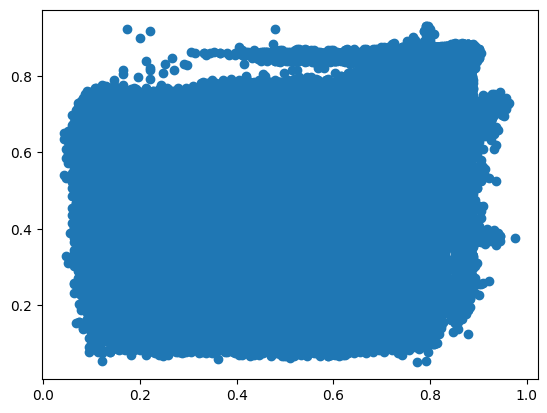

In [7]:
plt.scatter(S[0, :], S[2, :])

# Hyperparameters

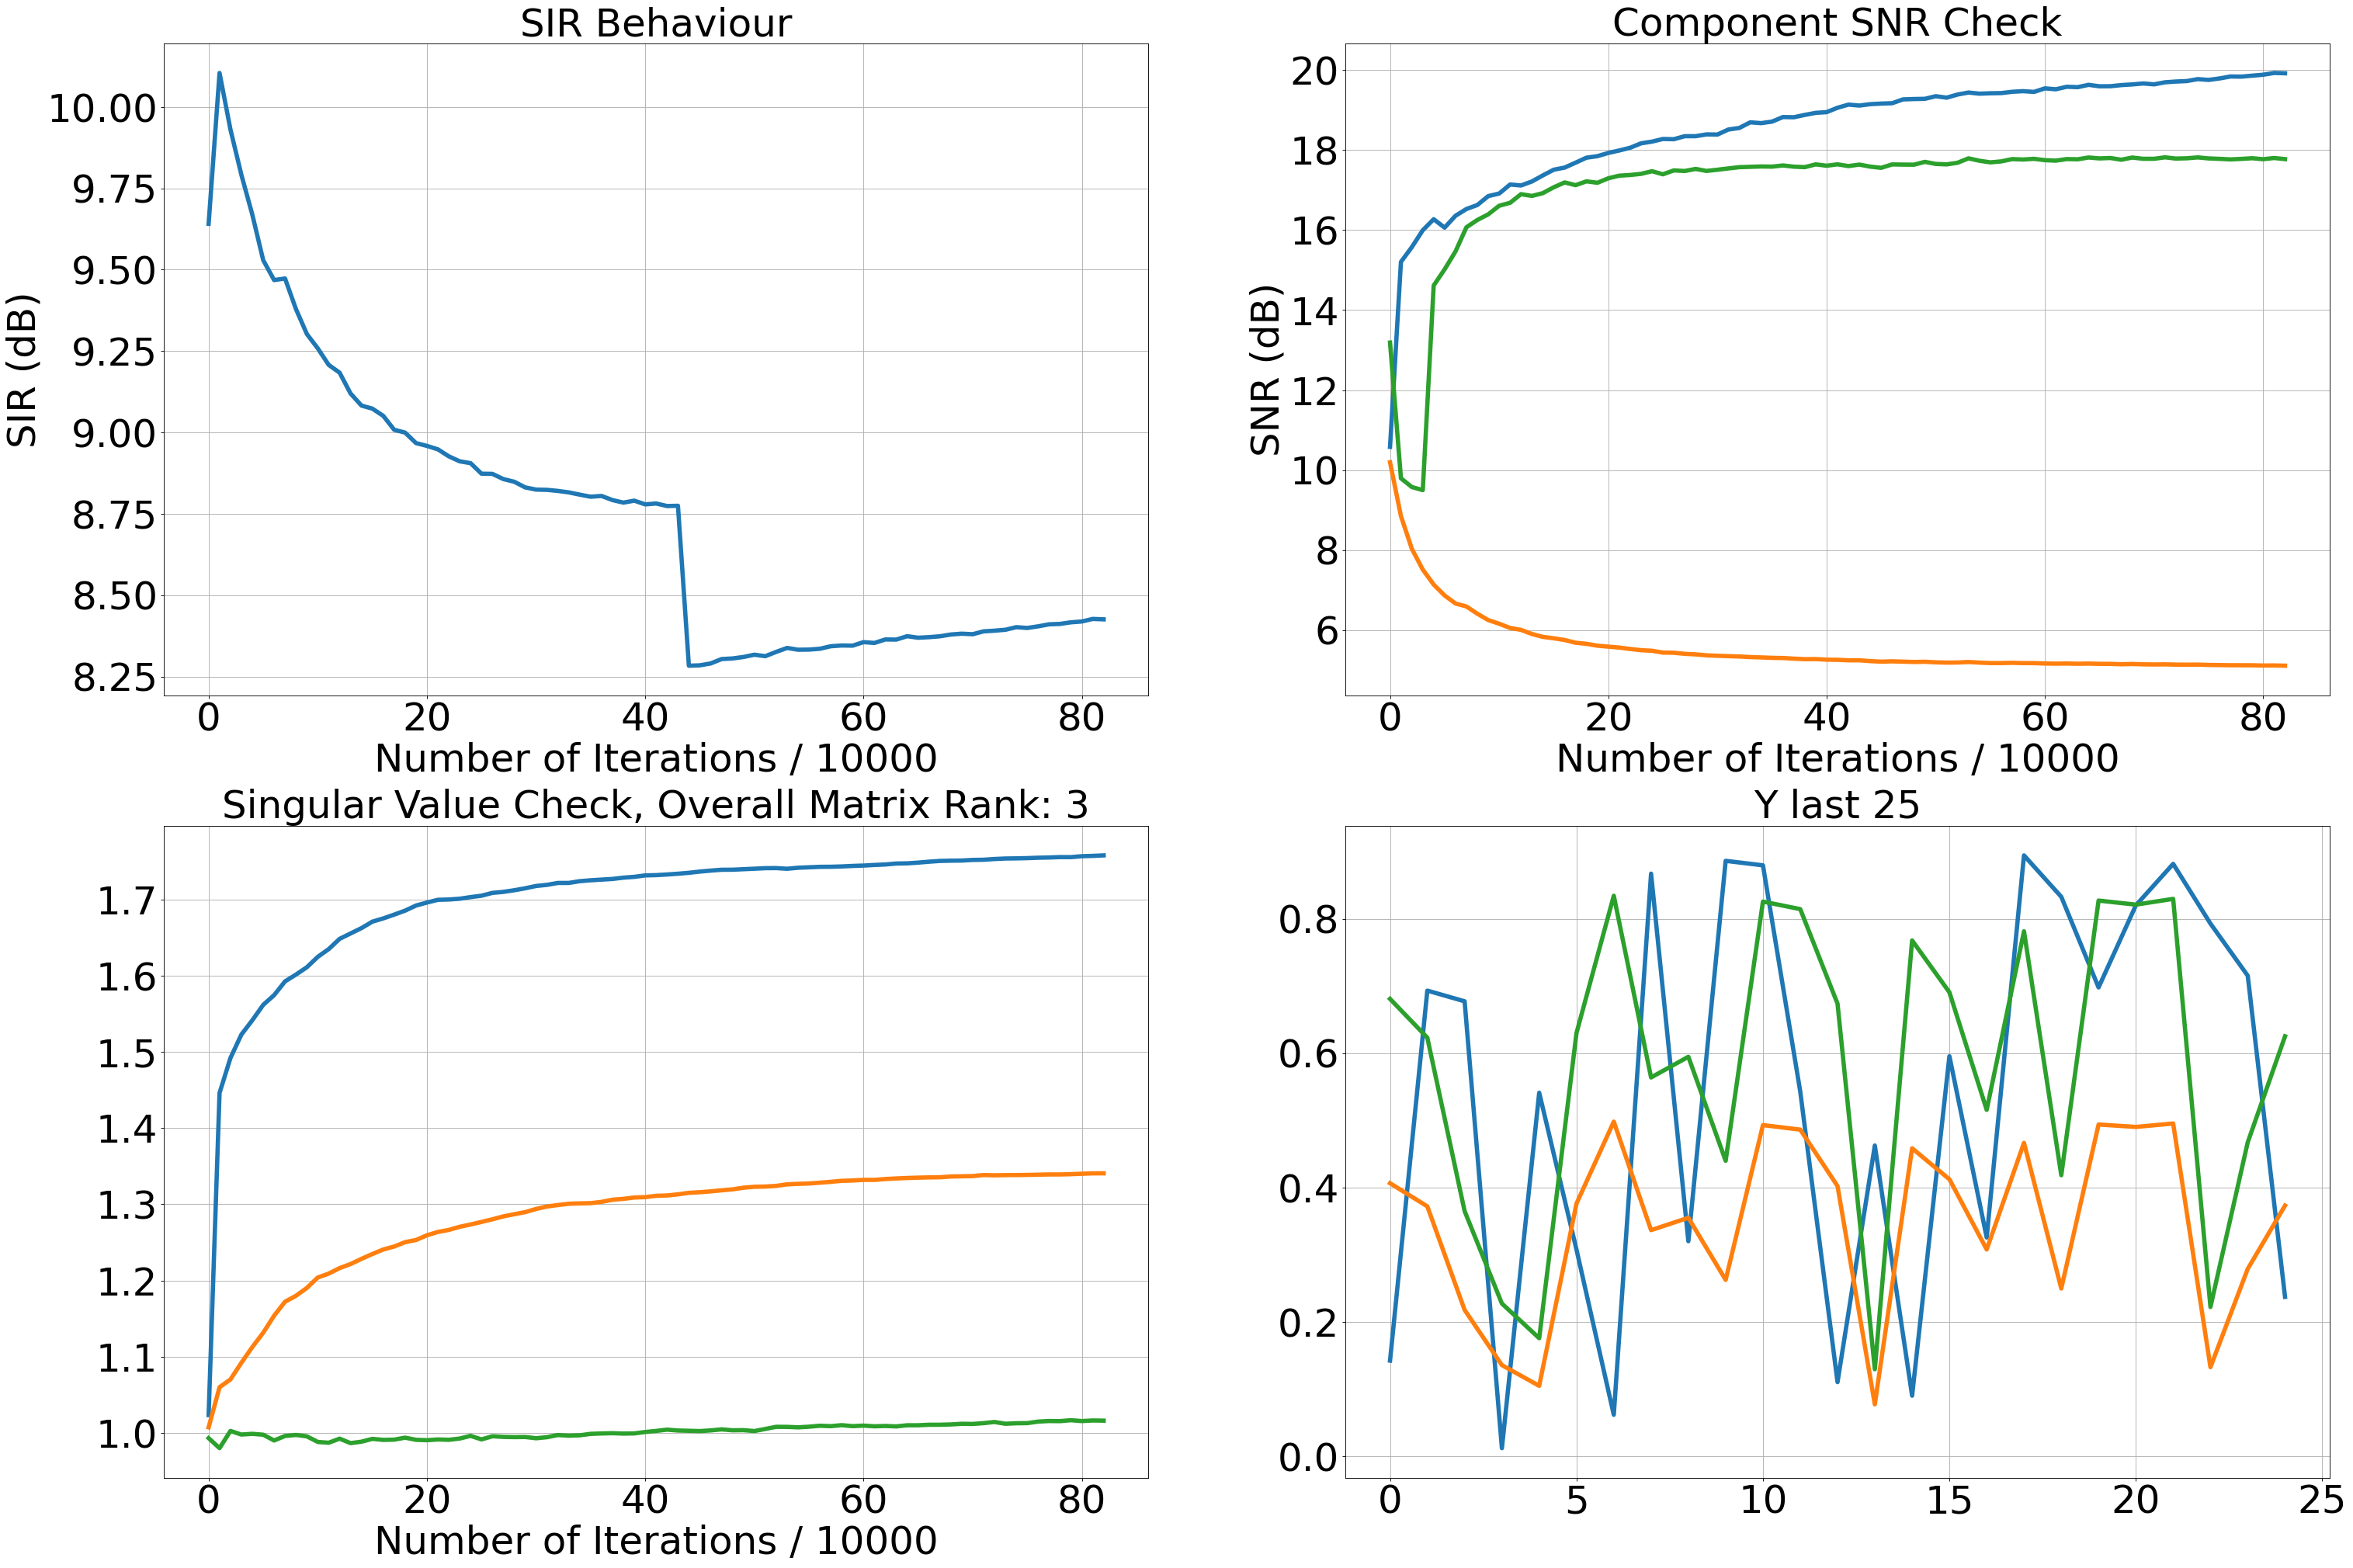

100%|██████████████████████████████████████████████████████████████████████████████████████████| 824010/824010 [02:25<00:00, 5675.26it/s]


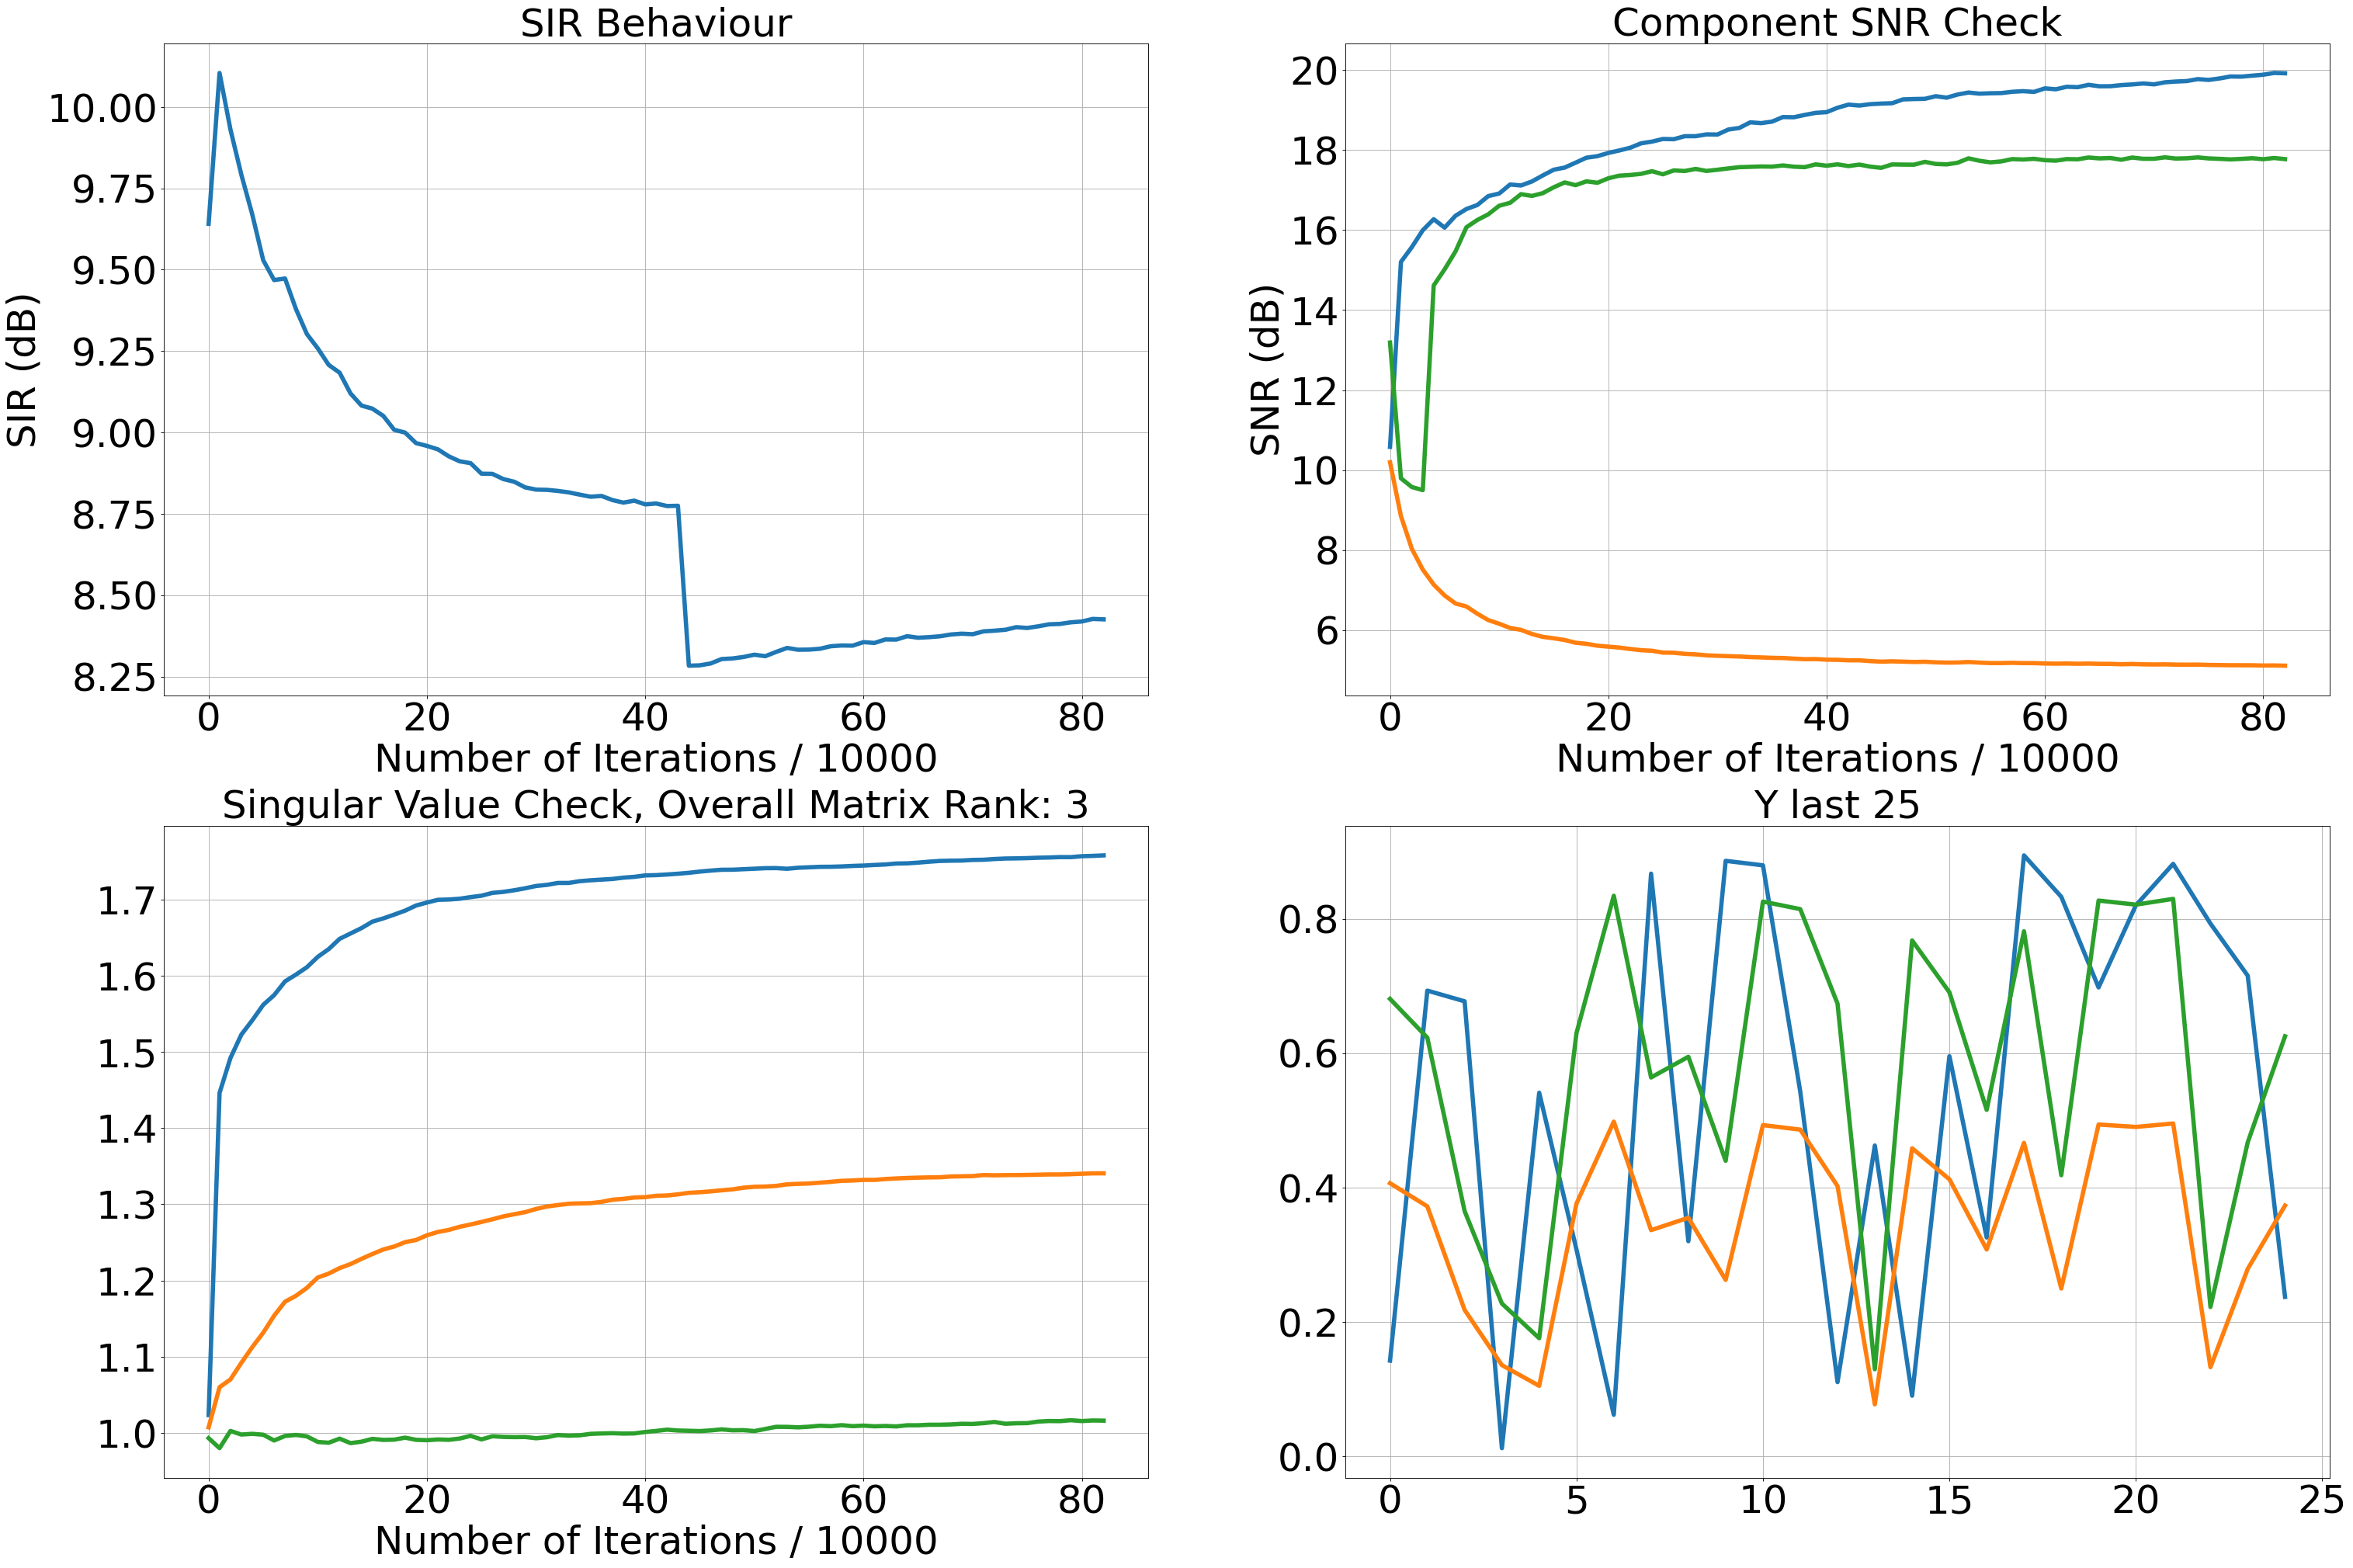

In [15]:
np.random.seed(seed)
hyperparam_dict = {
                "n_sources" :  NumberofSources,
                "presumed_domain" : "nnantisparse",
                ### Optimization parameters
                "lambda_lateral" : 0.95,
                "gamma_predictive" : 750,
                ### Learning rates 
                "lr_W" : 15 * 1e-2,
                "neural_lr_start" : 0.01,
                "neural_lr_stop" : 1e-6,
                "neural_dynamics_iterations" : 250,
                "neural_OUTPUT_COMP_TOL" : 1e-6,
                ### Learning rate rules and decay parameters
                "lr_W_rule" : "divide_by_index",
                "lr_W_decay_divider" : 5000,
                "neural_lr_rule" : "divide_by_loop_index",
                "neural_lr_decay_divider" : 200,
                ### Initial values for weights if provided, if not they will be initialized in the fit function 
                "W" : None,
                "C_y" : None,
                "mu_y" : None, 
                ### Ground truth source vectors. This part is only for debugging.
                "Sgt" : S,
                "debug_iteration_point" : 10000,
                "plot_debug_during_training" : True,
}
model = PredictiveDecorrBSS(**hyperparam_dict)
# model.C_y = np.eye(NumberofSources) / 1 + np.random.randn(NumberofSources, NumberofSources) / 15
# model.W = np.random.randn(NumberofSources, NumberofMixtures) / 10 + np.eye(NumberofSources, NumberofMixtures) 
# model.mu_y = 0.5 * np.ones(NumberofSources)
model.fit(X, shuffle_samples = True)

In [ ]:
display_matrix(model.C_y)

In [ ]:
display_matrix(model.mu_y.reshape(1, -1))

In [ ]:
display_matrix(model.W)

In [ ]:
Y_ = model.predict(X)
Y_ = model.signed_and_permutation_corrected_sources(S, Y_) # Find sign and permutation ambiguity
coef_ = ((Y_ * S).sum(axis=1) / (Y_ * Y_).sum(axis=1)).reshape(-1, 1) # Find if the extracted signals need some amplification! The networks learned weight may need amplification due to lateral connections during the neural dynamics!
Y_ = coef_ * Y_

print("Signal-to-Interference-and-Noise-Ratio (SINR): {}".format(model.ComputeSINR(S, Y_)))
print("Component Signal-to-Noise-Ratio (SNR) Values : {}\n".format(model.ComputeSNR(S, Y_)))

In [ ]:
visualize_flattened_images(Y_, imsize=(h, w))

# Plot for Publication

In [ ]:
def plot_image_separation_results(S_gt, X_mix, Y_rec, titles=None, save_path = None):
    """
    S_gt: Ground truth sources (n_sources, h, w)
    X_mix: Selected mixtures (e.g., first 3) (n_mixtures, h, w)
    Y_rec: Recovered sources (n_sources, h, w)
    """
    n_sources = S_gt.shape[0]
    fig, axes = plt.subplots(3, n_sources, figsize=(n_sources * 3, 10))
    
    rows = ['Ground Truth', 'Mixtures (Samples)', 'Recovered']
    
    for row_idx, data in enumerate([S_gt, X_mix[:n_sources], Y_rec]):
        for col_idx in range(n_sources):
            ax = axes[row_idx, col_idx]
            # Normalize for display
            img = data[col_idx]
            v_min, v_max = np.percentile(img, [1, 99])
            ax.imshow(img, cmap='gray', vmin=v_min, vmax=v_max)
            ax.set_xticks([])
            ax.set_yticks([])
            
            if col_idx == 0:
                ax.set_ylabel(rows[row_idx], fontsize=14, fontweight='bold')
            if row_idx == 0 and titles:
                ax.set_title(titles[col_idx], fontsize=12)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, format='pdf', bbox_inches = 'tight')
    plt.show()

In [ ]:
save_path = '../AnalyzeSimulationResults/Figures/Image_Separation_Comparison.pdf'
plot_image_separation_results(S.reshape(3, h, w), X.reshape(3, h, w), model.predict(X).reshape(3, h, w), save_path = save_path)